# OpenAI API Fundamentals
## Making Direct API Calls with the OpenAI Python SDK

**Estimated Time**: ~30 minutes

### Learning Objectives
- Initialize the OpenAI client and make text completion API calls
- Understand the message format: system, user, and assistant roles
- Inspect API response structure including token usage
- Use the Vision API to analyze images with multimodal models
- Extract structured JSON output using `response_format`

### Overview
In this lab you will work directly with the **OpenAI Python SDK** (`openai`) to make raw API calls -- no LangChain abstractions. This gives you a solid foundation in how LLM APIs work under the hood.

**Part 1** covers text completions: sending messages, receiving responses, and inspecting token usage.  
**Part 2** covers the Vision API: encoding images, sending multimodal requests, and extracting structured JSON.

In [11]:
import os
import json
import base64
from dotenv import load_dotenv, find_dotenv
from openai import OpenAI

load_dotenv(find_dotenv())

# Verify API key is set
assert os.getenv("OPENAI_API_KEY"), "Please set OPENAI_API_KEY in your .env file"
print("Environment loaded successfully!")

Environment loaded successfully!


---
## Part 1: Text Completion

The core of the OpenAI API is the **Chat Completions** endpoint. Here is how it works:

1. **Initialize a client**: `client = OpenAI()` -- this reads your `OPENAI_API_KEY` from the environment automatically.
2. **Call `client.chat.completions.create()`** with:
   - `model` -- which model to use (e.g., `gpt-4o-mini`)
   - `messages` -- a list of message dictionaries, each with a `role` and `content`
3. **Read the response**: The API returns a `ChatCompletion` object with a list of `choices`.

### Message Roles
| Role | Purpose |
|------|--------|
| `system` | Sets the assistant's persona and instructions (optional but recommended) |
| `user` | The human's input / question |
| `assistant` | Previous assistant responses (for multi-turn conversations) |

In [12]:
# Initialize the OpenAI client
client = OpenAI()
print("OpenAI client initialized.")

OpenAI client initialized.


In [13]:
# Make a simple text completion call
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "user", "content": "Explain what SQL injection is in 3 sentences."}
    ]
)

print("API call successful!")
print(f"Response type: {type(response).__name__}")

API call successful!
Response type: ChatCompletion


In [14]:
# Extract and print the response content
content = response.choices[0].message.content
print(content)

SQL injection is a type of cyber attack where an attacker exploits vulnerabilities in an application's software by inserting or "injecting" malicious SQL code into a query. This can allow the attacker to manipulate the database, potentially gaining unauthorized access to sensitive data or altering the database's contents. Effective preventive measures, such as using prepared statements and parameterized queries, are essential to safeguard applications from this threat.


---
### Response Structure

The API response is a `ChatCompletion` object with this structure:

```
ChatCompletion(
    id='chatcmpl-...',
    choices=[
        Choice(
            message=ChatCompletionMessage(
                role='assistant',
                content='The actual text response...'
            ),
            finish_reason='stop'
        )
    ],
    usage=CompletionUsage(
        prompt_tokens=14,
        completion_tokens=87,
        total_tokens=101
    )
)
```

Key fields:
- **`choices[0].message.content`** -- the model's text response
- **`choices[0].finish_reason`** -- why the model stopped (`stop` = natural end, `length` = hit token limit)
- **`usage`** -- token counts for billing and monitoring

In [15]:
# Print token usage from the response
usage = response.usage
print(f"Prompt tokens:     {usage.prompt_tokens}")
print(f"Completion tokens: {usage.completion_tokens}")
print(f"Total tokens:      {usage.total_tokens}")

Prompt tokens:     17
Completion tokens: 78
Total tokens:      95


---
### System Messages, Temperature, and Model Selection

**System messages** set the persona and constraints for the model. They go first in the `messages` list and are especially useful for:
- Defining the assistant's role ("You are a cybersecurity analyst...")
- Setting output format constraints
- Providing background context

**Temperature** controls randomness:
- `temperature=0` -- deterministic, best for factual/analytical tasks
- `temperature=0.7` -- balanced creativity (default)
- `temperature=1.0+` -- more creative/varied outputs

**Model selection** trades off cost, speed, and capability:
- `gpt-4o-mini` -- fast and cheap, great for most tasks
- `gpt-4o` -- more capable, better for complex reasoning

In [20]:
# Multi-message call with system prompt
response = client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0,
    messages=[
        {
            "role": "system",
            "content": (
                "You are a senior cybersecurity analyst at a Fortune 500 company. "
                "You provide clear, actionable security advice. "
                "Keep responses concise and technical."
            )
        },
        {
            "role": "user",
            "content": "What are the top 3 indicators that an email is a phishing attempt?"
        }
    ]
)

print(response.choices[0].message.content)

1. **Suspicious Sender Address**: Check for slight misspellings or unusual domains in the sender's email address that mimic legitimate organizations (e.g., support@paypa1.com instead of support@paypal.com).

2. **Urgent or Threatening Language**: Phishing emails often create a sense of urgency or fear, prompting immediate action (e.g., "Your account will be suspended unless you verify your information now!").

3. **Unusual Links or Attachments**: Hover over links to see the actual URL before clicking. Phishing emails may contain links that lead to malicious sites or unexpected attachments that could contain malware.


---
## Part 2: Vision API - Vehicle Image Analysis

OpenAI's multimodal models (like `gpt-4o-mini`) can process **both text and images** in a single API call. This is called the **Vision API**.

How it works:
1. **Load an image** from disk and encode it as a **base64** string
2. **Build a data URI**: `data:image/jpeg;base64,<encoded_string>`
3. **Send a message** where `content` is a **list** of content blocks:
   - `{"type": "text", "text": "your prompt"}` -- the text instruction
   - `{"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,..."}}` -- the image

The model sees both the text and the image and generates a response based on both.

In [21]:
# Load image from disk and encode to base64
image_path = "../data/car2.jpg"

with open(image_path, "rb") as f:
    image_bytes = f.read()

image_base64 = base64.b64encode(image_bytes).decode("utf-8")
data_uri = f"data:image/jpeg;base64,{image_base64}"

print(f"Image loaded: {len(image_bytes):,} bytes")
print(f"Base64 length: {len(image_base64):,} characters")
print(f"Data URI prefix: {data_uri[:50]}...")

Image loaded: 47,557 bytes
Base64 length: 63,412 characters
Data URI prefix: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD...


''
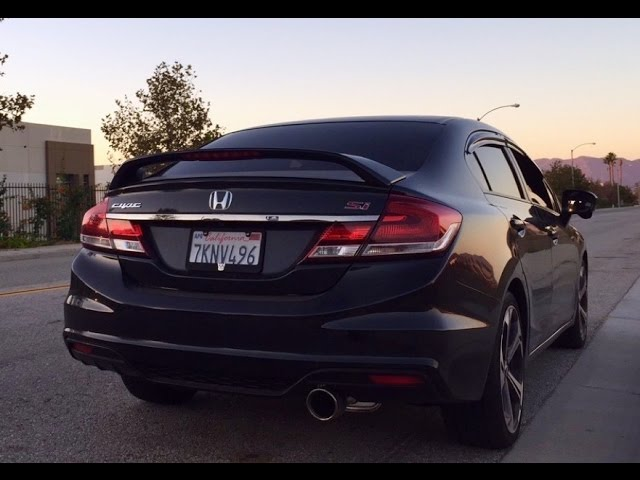

In [23]:
data_uri

---
### Vision Message Format

For vision calls, the `content` field of a message is a **list** instead of a plain string:

```python
messages=[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Describe this image."},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,..."}
            }
        ]
    }
]
```

You can include multiple images by adding more `image_url` blocks.

In [24]:
# Make a vision API call asking for a JSON description of the vehicle
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "Analyze this vehicle image and return a JSON object with the following fields: "
                        "make, model, color, body_type, approximate_year, condition, notable_features, "
                        "license_plate, state_registration. "
                        "For license_plate and state_registration, extract the values if visible, otherwise use null. "
                        "Return ONLY the JSON object, no other text."
                    )
                },
                {
                    "type": "image_url",
                    "image_url": {"url": data_uri}
                }
            ]
        }
    ]
)

raw_content = response.choices[0].message.content
print("Raw response:")
print(raw_content)

Raw response:
```json
{
  "make": "Honda",
  "model": "Civic Si",
  "color": "Black",
  "body_type": "Sedan",
  "approximate_year": 2016,
  "condition": "Good",
  "notable_features": ["Sporty design", "Spoiler", "Custom rims"],
  "license_plate": "7KNVL96",
  "state_registration": "California"
}
```


In [25]:
# Parse the JSON response and pretty-print it
# The model might wrap JSON in ```json ... ``` markdown -- strip that if present
json_str = raw_content.strip()
if json_str.startswith("```"):
    json_str = json_str.split("\n", 1)[1]  # Remove first line (```json)
    json_str = json_str.rsplit("```", 1)[0]  # Remove closing ```

vehicle_data = json.loads(json_str)
print(json.dumps(vehicle_data, indent=2))

{
  "make": "Honda",
  "model": "Civic Si",
  "color": "Black",
  "body_type": "Sedan",
  "approximate_year": 2016,
  "condition": "Good",
  "notable_features": [
    "Sporty design",
    "Spoiler",
    "Custom rims"
  ],
  "license_plate": "7KNVL96",
  "state_registration": "California"
}


In [26]:
vehicle_data['model']

'Civic Si'

---
### Structured Output with `response_format`

Asking the model to "return JSON" in the prompt works most of the time, but the model might:
- Wrap the JSON in markdown code fences
- Add explanatory text before or after the JSON
- Return invalid JSON

The `response_format={"type": "json_object"}` parameter **guarantees** the model returns valid JSON:
- The entire response is a single JSON object
- No markdown fences or extra text
- Parsing with `json.loads()` is always safe

**Important**: When using `response_format={"type": "json_object"}`, you must still mention "JSON" in your prompt -- the API requires this.

In [27]:
# Repeat the call with response_format for guaranteed JSON output
response = client.chat.completions.create(
    model="gpt-4o-mini",
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "Analyze this vehicle image and return a JSON object with the following fields: "
                        "make, model, color, body_type, approximate_year, condition, notable_features, "
                        "license_plate, state_registration. "
                        "For license_plate and state_registration, extract the values if visible, otherwise use null. "
                        "Return ONLY valid JSON."
                    )
                },
                {
                    "type": "image_url",
                    "image_url": {"url": data_uri}
                }
            ]
        }
    ]
)

structured_content = response.choices[0].message.content
print("Structured response (guaranteed JSON):")
print(structured_content)

Structured response (guaranteed JSON):
{
  "make": "Honda",
  "model": "Civic",
  "color": "black",
  "body_type": "sedan",
  "approximate_year": 2015,
  "condition": "good",
  "notable_features": ["S1 trim", "spoiler"],
  "license_plate": "7KNVL96",
  "state_registration": "California"
}


In [28]:
# Parse and display the structured JSON
vehicle_data = json.loads(structured_content)
print(json.dumps(vehicle_data, indent=2))

print("\n--- Vehicle Summary ---")
for key, value in vehicle_data.items():
    print(f"  {key}: {value}")

{
  "make": "Honda",
  "model": "Civic",
  "color": "black",
  "body_type": "sedan",
  "approximate_year": 2015,
  "condition": "good",
  "notable_features": [
    "S1 trim",
    "spoiler"
  ],
  "license_plate": "7KNVL96",
  "state_registration": "California"
}

--- Vehicle Summary ---
  make: Honda
  model: Civic
  color: black
  body_type: sedan
  approximate_year: 2015
  condition: good
  notable_features: ['S1 trim', 'spoiler']
  license_plate: 7KNVL96
  state_registration: California


---
## Checkpoint Checklist

Before moving on, verify:

- [ ] Part 1: Simple text completion returns a coherent answer about SQL injection
- [ ] Part 1: Token usage prints prompt, completion, and total token counts
- [ ] Part 1: Multi-message call with system prompt returns cybersecurity-focused response
- [ ] Part 2: Image loads and base64 encodes without errors
- [ ] Part 2: Vision API returns a description of the vehicle
- [ ] Part 2: `response_format={"type": "json_object"}` returns clean, parseable JSON
- [ ] Part 2: JSON contains expected fields (make, model, color, body_type, license_plate, state_registration, etc.)

### Discussion Questions

1. What happens if you increase `temperature` to 1.0? How does the response change?
2. Why might `response_format={"type": "json_object"}` be preferable to just asking for JSON in the prompt?
3. How could you use the Vision API for cybersecurity? (Think: screenshot analysis, document verification, CAPTCHA detection)
4. What are the cost implications of sending images vs. text? (Hint: check the token usage for vision calls)